In [33]:
#%matplotlib widget
import sympy as sym
from sympy.utilities.lambdify import lambdastr
from sympy.plotting import plot3d, plot_contour
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import ipywidgets as widgets
from ipywidgets import interactive

In [2]:
eta, nth, nsq, n =sym.symbols('eta n_th n_sq n')

In [3]:
a = 2*nsq*eta +2*nth*(1-eta) +1
b = 2*nsq + 1
c = 2*sym.sqrt(eta*nsq*(nsq+1))

In [4]:
yp = (a+b)**2-4*c**2

In [5]:
ym = (a+b)**2-4*c**2

In [6]:
nup = (yp/sym.sqrt(ym) +(a-b))/2

In [7]:
num = (yp/sym.sqrt(ym) -(a-b))/2

In [8]:
sym.simplify(sym.cancel(nup))

eta*n_sq - eta*n_th - n_sq + n_th + sqrt(eta**2*n_sq**2 - 2*eta**2*n_sq*n_th + eta**2*n_th**2 - 2*eta*n_sq**2 - 2*eta*n_sq - 2*eta*n_th**2 - 2*eta*n_th + n_sq**2 + 2*n_sq*n_th + 2*n_sq + n_th**2 + 2*n_th + 1)

In [9]:
QFI = 2*sym.simplify(c**2/(nup*num+1))

In [10]:
sym.factor(sym.cancel(QFI))

-4*eta*n_sq*(n_sq + 1)/(2*eta*n_sq*n_th + eta*n_sq + eta*n_th - 2*n_sq*n_th - n_sq - n_th - 1)

In [11]:
print(sym.latex(sym.factor(sym.cancel(QFI))))

- \frac{4 \eta n_{sq} \left(n_{sq} + 1\right)}{2 \eta n_{sq} n_{th} + \eta n_{sq} + \eta n_{th} - 2 n_{sq} n_{th} - n_{sq} - n_{th} - 1}


In [12]:
lambdastr([eta,nth,nsq],QFI)

'lambda eta,n_th,n_sq: (4*eta*n_sq*(-n_sq - 1)/(2*eta*n_sq*n_th + eta*n_sq + eta*n_th - 2*n_sq*n_th - n_sq - n_th - 1))'

In [13]:
sym.cancel(QFI.subs(eta,1))

4*n_sq**2 + 4*n_sq

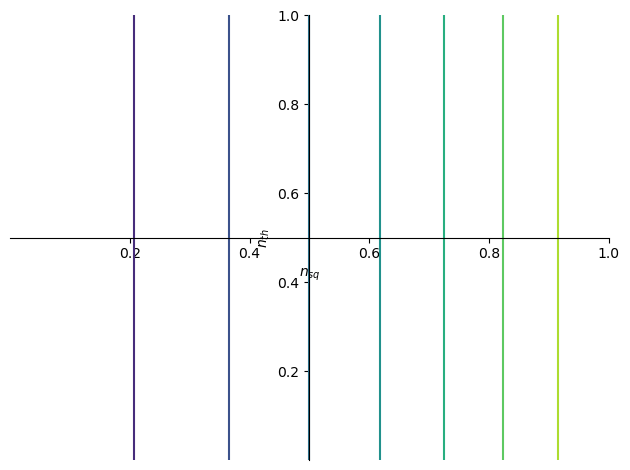

In [14]:
plot_contour(QFI.subs(eta,1),(nsq,0.0001,1),(nth,0.0001,1))

In [15]:
adjusted = sym.cancel(QFI/nsq)

In [16]:
adjusted

(-4*eta*n_sq - 4*eta)/(2*eta*n_sq*n_th + eta*n_sq + eta*n_th - 2*n_sq*n_th - n_sq - n_th - 1)

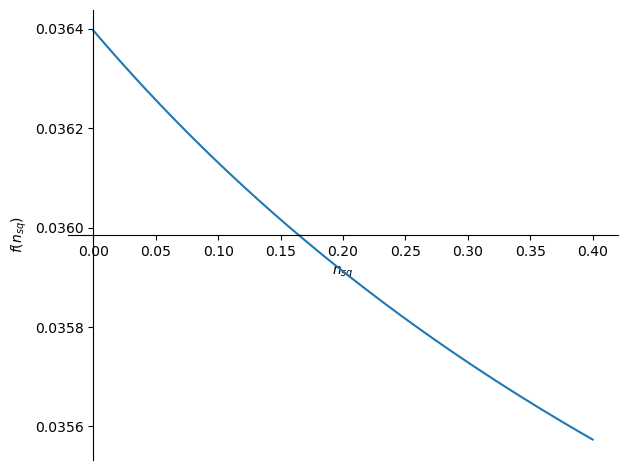

In [17]:
sym.plot(adjusted.subs(eta,.01).subs(nth,.1),(nsq,0,.4))

In [18]:
constantQFI = (1+n)*QFI.subs(nsq,nsq/(n+1))

In [19]:
constantQFI

4*eta*n_sq*(-n_sq/(n + 1) - 1)/(2*eta*n_sq*n_th/(n + 1) + eta*n_sq/(n + 1) + eta*n_th - 2*n_sq*n_th/(n + 1) - n_sq/(n + 1) - n_th - 1)

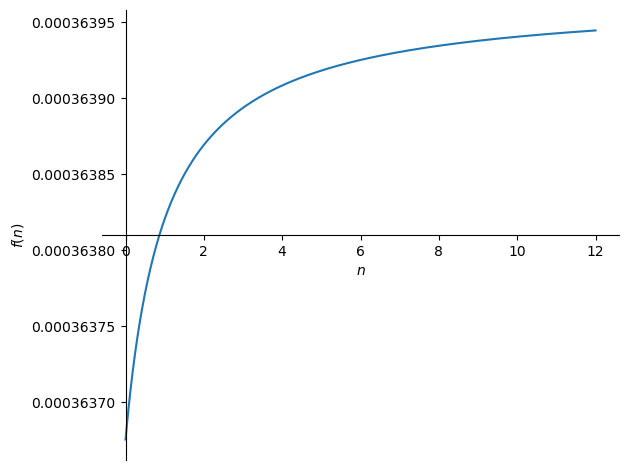

In [20]:
sym.plot(constantQFI.subs(eta,.01).subs(nth,.1).subs(nsq,.01),(n,0,12))

In [21]:
QFI.subs(eta,.1).subs(nth,.1).subs(nsq,np.sinh(.1)**2)

0.00368230909512915

In [22]:
QFI.subs(eta,.1).subs(nth,.1).subs(nsq,np.sqrt(.1*.9**2*2))

0.148093484731179

In [23]:
np.sqrt(.1*.9**2*2)

np.float64(0.4024922359499622)

In [24]:
qoi = sym.cancel(adjusted.diff(nsq)/adjusted).subs(nsq,0)

In [25]:
qoi >0

(-eta*n_th - eta + n_th)/(eta*n_th - n_th - 1) > 0

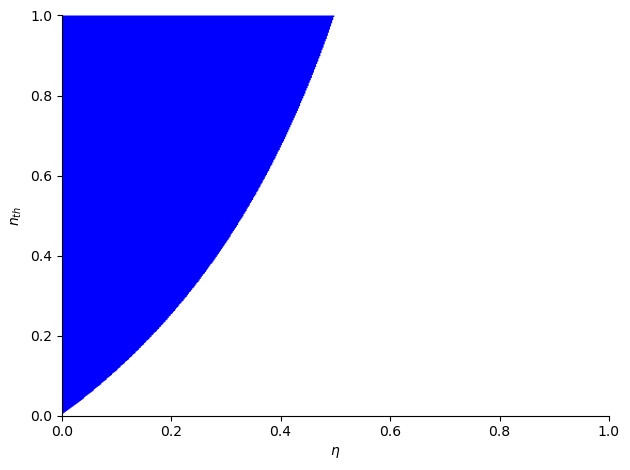

In [26]:
sym.plot_implicit(-qoi>0,(eta,0,1),(nth,0,1))

In [46]:
squeezeSlider = widgets.FloatLogSlider(1,base=10,min=-9,max=1)
points = np.linspace(0,1,100)
[etas,nths] = np.meshgrid(points,points)
def interactive_plot(nsqval):
    QFIDiff = nsqval*adjusted.subs(nsq,0) - QFI.subs(nsq,nsqval)
    evalfun = sym.lambdify([eta,nth],QFIDiff)
    diffs = evalfun(etas,nths)
    #plt.subplots_adjust(right=.6)
    fig, ax = plt.subplots()
    cs = ax.contourf(etas,nths,diffs,levels=10,locator=ticker.LinearLocator())
    ax.set_ylabel(r'$n_{th}$')
    ax.set_xlabel(r'$\eta$')
    #cax = plt.axes((0.85, 0.1, 0.075, 0.8))
    fig.colorbar(cs,ax=ax, label='QFI advantage',fraction=.1)
    #ax.set_aspect(.6)
    #ax.autoscale_view(True,scalex=False,scaley=False)
    #cax.autoscale_view(True)
    plt.show()
iplot = interactive(interactive_plot,nsqval=squeezeSlider)
output = iplot.children[1]
output.layout.height = '600px'
#output.layout.width='600px'
iplot

interactive(children=(FloatLogSlider(value=1.0, description='nsqval', max=1.0, min=-9.0), Output(layout=Layout…

In [28]:
sym.plot(adjusted.subs(eta,1).subs(nth,.57/(1-.57)),(nsq,0,.4))

ValueError: 
$f{\left(n_{sq} \right)}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

In [ ]:
sym.plot_implicit(-(nth-eta)/(-nth-1)>0,(eta,0,1),(nth,0,1), Adaptive=False)

In [ ]:
adjusted.limit(nsq,0)